## 1. Imports & Config

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

# ── Plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'     : 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size'      : 10,
})
PALETTE = ['#4C72B0', '#55A868', '#C44E52']   # LR / RF / XGB

print('All imports successful.')

All imports successful.


## 2. Load & Prepare Both Datasets

In [2]:
#Loading and preparing datasets for both CKD and Diabetes
# ── CKD ────────────────────────────────────────────────────
ckd_df = pd.read_csv('../data/chronic_kidney_disease/ckd_cleaned.csv')
X_ckd  = ckd_df.drop(columns=['classification'])
y_ckd  = ckd_df['classification']

X_ckd_tr, X_ckd_te, y_ckd_tr, y_ckd_te = train_test_split(
    X_ckd, y_ckd, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ckd
)

# ── Diabetes ────────────────────────────────────────────────
dia_df  = pd.read_csv('../data/diabetes/diabetes_cleaned.csv')
X_dia   = dia_df.drop(columns=['Outcome'])
y_dia   = dia_df['Outcome']

X_dia_tr, X_dia_te, y_dia_tr, y_dia_te = train_test_split(
    X_dia, y_dia, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dia
)

print('CKD      — train:', X_ckd_tr.shape, '| test:', X_ckd_te.shape)
print('Diabetes — train:', X_dia_tr.shape, '| test:', X_dia_te.shape)

CKD      — train: (320, 24) | test: (80, 24)
Diabetes — train: (614, 8) | test: (154, 8)


## 3.Build & Train All 3 Models (Both Datasets)

In [3]:
#Build & Train All 3 Models (Both Datasets)
#Each model is wrapped in an `ImbPipeline` (SMOTE inside CV fold — no leakage), then tuned with `GridSearchCV`.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Pipeline factory ────────────────────────────────────────
def make_pipelines():
    lr_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
    lr_grid = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l1','l2'],
               'clf__solver': ['liblinear']}

    rf_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    rf_grid = {'clf__n_estimators': [100, 200],
               'clf__max_depth'   : [None, 10, 20],
               'clf__min_samples_split': [2, 5]}

    xgb_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    XGBClassifier(eval_metric='logloss',
                                 use_label_encoder=False,
                                 random_state=RANDOM_STATE,
                                 n_jobs=-1))
    ])
    xgb_grid = {'clf__n_estimators': [100, 200],
                'clf__max_depth'   : [3, 6],
                'clf__learning_rate': [0.05, 0.1]}

    return [
        ('Logistic Regression', lr_pipe,  lr_grid),
        ('Random Forest',       rf_pipe,  rf_grid),
        ('XGBoost',             xgb_pipe, xgb_grid),
    ]

# ── Training function ───────────────────────────────────────
def train_all(X_tr, y_tr, X_te, y_te, dataset_name):
    results = {}
    trained = {}

    for name, pipe, param_grid in make_pipelines():
        gs = GridSearchCV(pipe, param_grid, cv=skf,
                          scoring='roc_auc', n_jobs=-1, verbose=0)
        gs.fit(X_tr, y_tr)
        best = gs.best_estimator_

        y_pred = best.predict(X_te)
        y_prob = best.predict_proba(X_te)[:, 1]

        results[name] = {
            'Accuracy' : round(accuracy_score(y_te, y_pred),  4),
            'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
            'Recall'   : round(recall_score(y_te, y_pred),    4),
            'F1-Score' : round(f1_score(y_te, y_pred),        4),
            'ROC-AUC'  : round(roc_auc_score(y_te, y_prob),   4),
        }
        trained[name] = best
        print(f'  [{dataset_name}] {name:<22} — Best CV AUC: {gs.best_score_:.4f} | Test AUC: {results[name]["ROC-AUC"]}')

    return results, trained

print('Training CKD models...')
ckd_results, ckd_models = train_all(X_ckd_tr, y_ckd_tr, X_ckd_te, y_ckd_te, 'CKD')

print('\nTraining Diabetes models...')
dia_results, dia_models = train_all(X_dia_tr, y_dia_tr, X_dia_te, y_dia_te, 'Diabetes')

print('\n  All models trained.')

Training CKD models...
  [CKD] Logistic Regression    — Best CV AUC: 1.0000 | Test AUC: 1.0
  [CKD] Random Forest          — Best CV AUC: 0.9998 | Test AUC: 1.0
  [CKD] XGBoost                — Best CV AUC: 0.9988 | Test AUC: 1.0

Training Diabetes models...
  [Diabetes] Logistic Regression    — Best CV AUC: 0.8443 | Test AUC: 0.8083
  [Diabetes] Random Forest          — Best CV AUC: 0.8303 | Test AUC: 0.8137
  [Diabetes] XGBoost                — Best CV AUC: 0.8293 | Test AUC: 0.8231

  All models trained.


## 4. Metric Tables

In [4]:
# Metric Tables
ckd_df_res  = pd.DataFrame(ckd_results).T
dia_df_res  = pd.DataFrame(dia_results).T

metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

print('=' * 60)
print('  CHRONIC KIDNEY DISEASE — Test Set Results')
print('=' * 60)
print(ckd_df_res[metrics].to_string())

print('\n' + '=' * 60)
print('  DIABETES — Test Set Results')
print('=' * 60)
print(dia_df_res[metrics].to_string())

# Highlight best per column
print('\n── Best per metric ──')
for ds_name, df_r in [('CKD', ckd_df_res), ('Diabetes', dia_df_res)]:
    print(f'\n{ds_name}:')
    for m in metrics:
        best_model = df_r[m].idxmax()
        best_val   = df_r[m].max()
        print(f'  {m:<12} → {best_model} ({best_val:.4f})')

  CHRONIC KIDNEY DISEASE — Test Set Results
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8875        1.0    0.82    0.9011      1.0
Random Forest          1.0000        1.0    1.00    1.0000      1.0
XGBoost                1.0000        1.0    1.00    1.0000      1.0

  DIABETES — Test Set Results
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7078     0.5738  0.6481    0.6087   0.8083
Random Forest          0.7208     0.5797  0.7407    0.6504   0.8137
XGBoost                0.7273     0.5857  0.7593    0.6613   0.8231

── Best per metric ──

CKD:
  Accuracy     → Random Forest (1.0000)
  Precision    → Logistic Regression (1.0000)
  Recall       → Random Forest (1.0000)
  F1-Score     → Random Forest (1.0000)
  ROC-AUC      → Logistic Regression (1.0000)

Diabetes:
  Accuracy     → XGBoost (0.7273)
  Precision    → XGBoost (0.5857)
  Recall       → XGBoost (0.7593)
  F1-Score     → XGBoost (0

In [5]:
OUTPUT_DIR = "../outputs/final_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 5. Side-by-Side Bar Charts per Metric

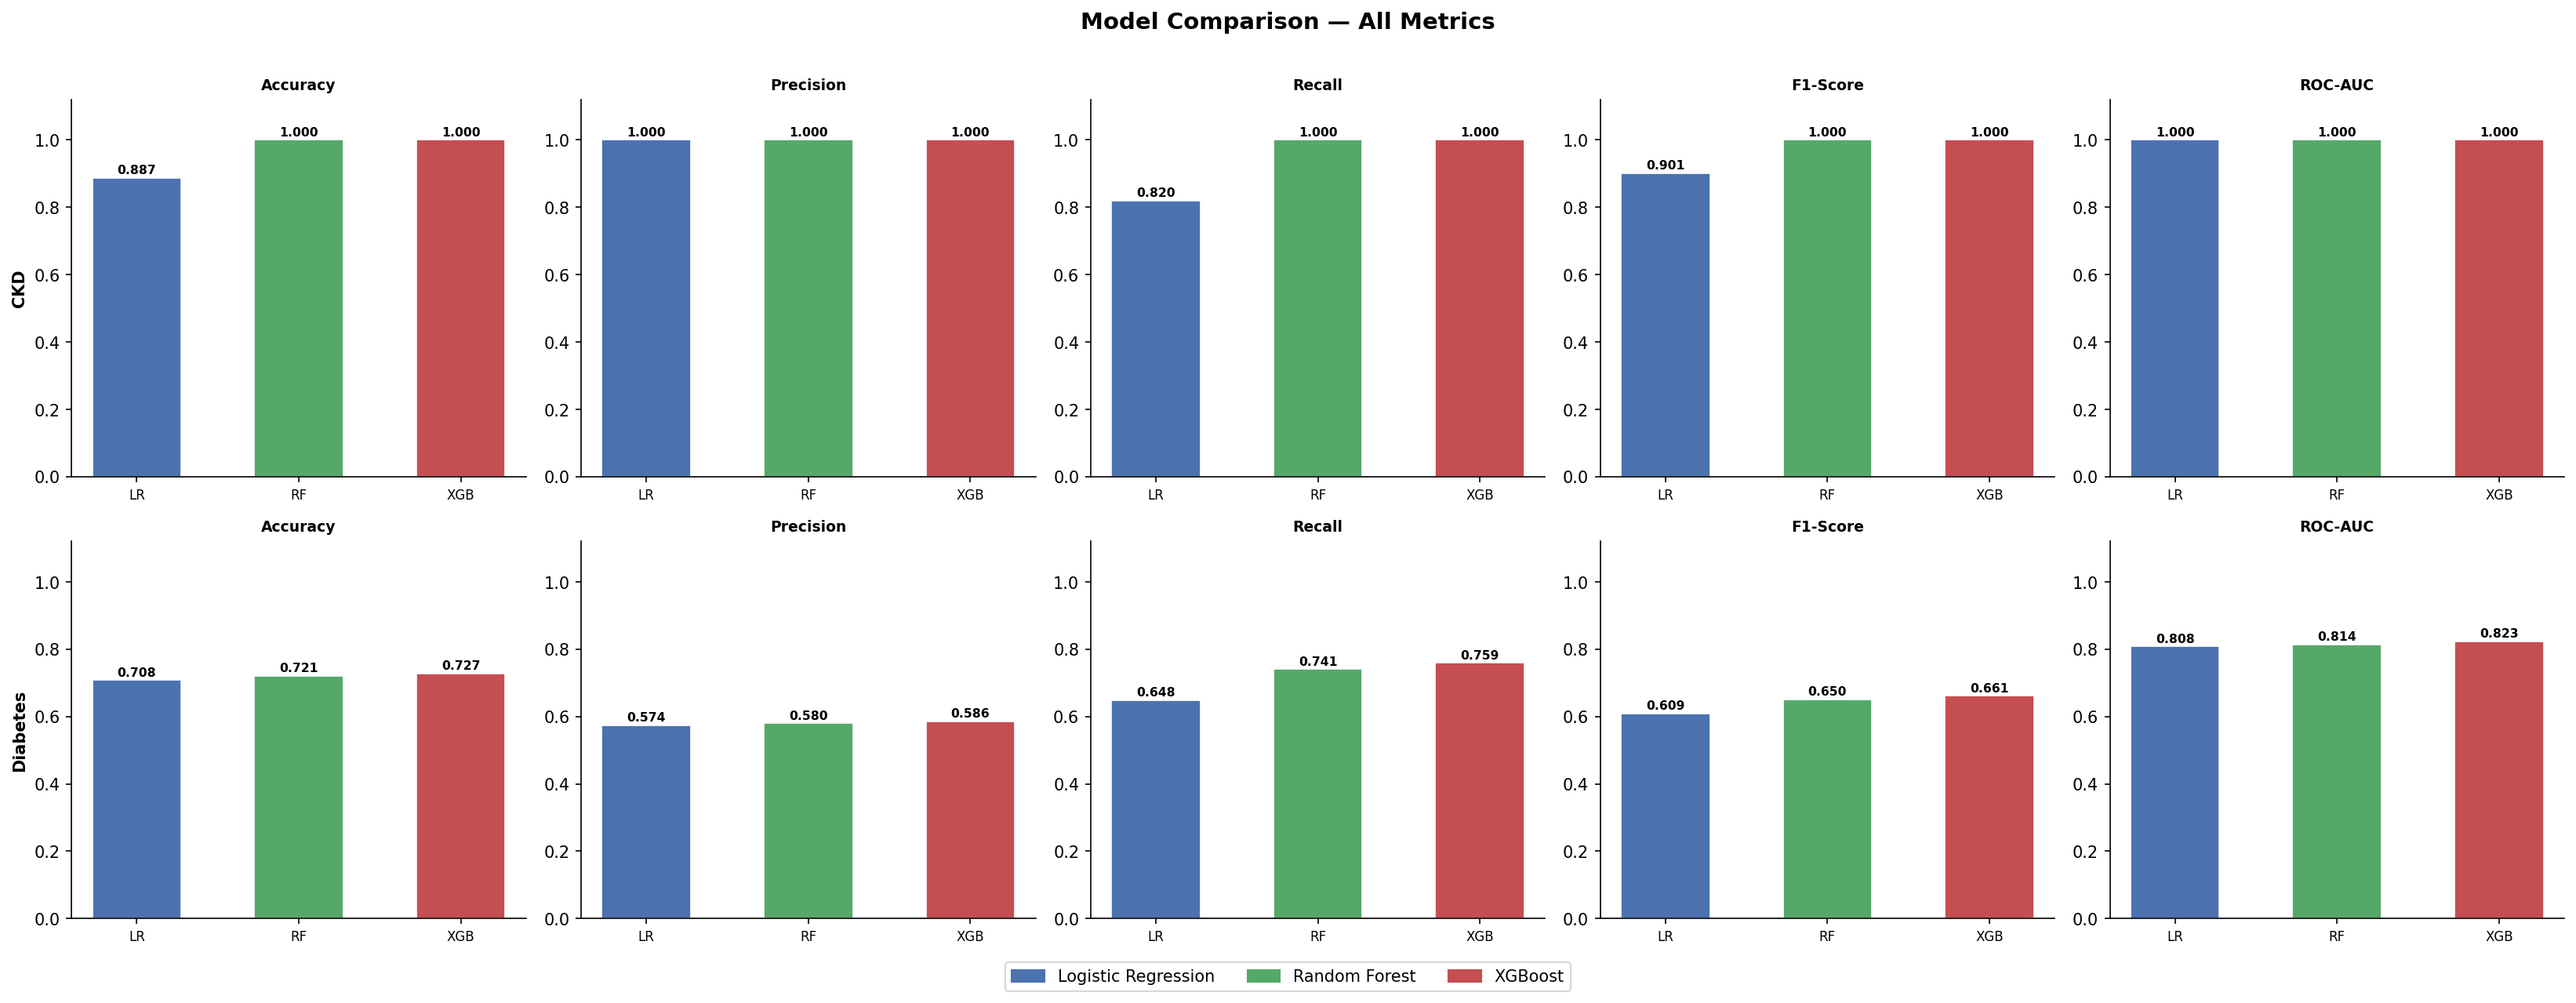

Saved: ../outputs/final_model/metric_comparison_bars.png


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
fig.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold', y=1.01)

model_names = list(ckd_results.keys())
x = np.arange(len(model_names))
bar_w = 0.55

datasets = [
    ('CKD',      ckd_df_res,  axes[0]),
    ('Diabetes', dia_df_res,  axes[1]),
]

for row_idx, (ds_name, df_r, row_axes) in enumerate(datasets):
    for col_idx, metric in enumerate(metrics):
        ax = row_axes[col_idx]
        vals = df_r[metric].values
        bars = ax.bar(x, vals, width=bar_w, color=PALETTE, edgecolor='white', linewidth=0.8)

        # Value labels
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(['LR', 'RF', 'XGB'], fontsize=8)
        ax.set_ylim(0, 1.12)
        ax.set_title(metric, fontsize=9, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(ds_name, fontsize=10, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color=PALETTE[i], label=model_names[i]) for i in range(3)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/metric_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/metric_comparison_bars.png')

## 6. ROC Curves — Both Datasets

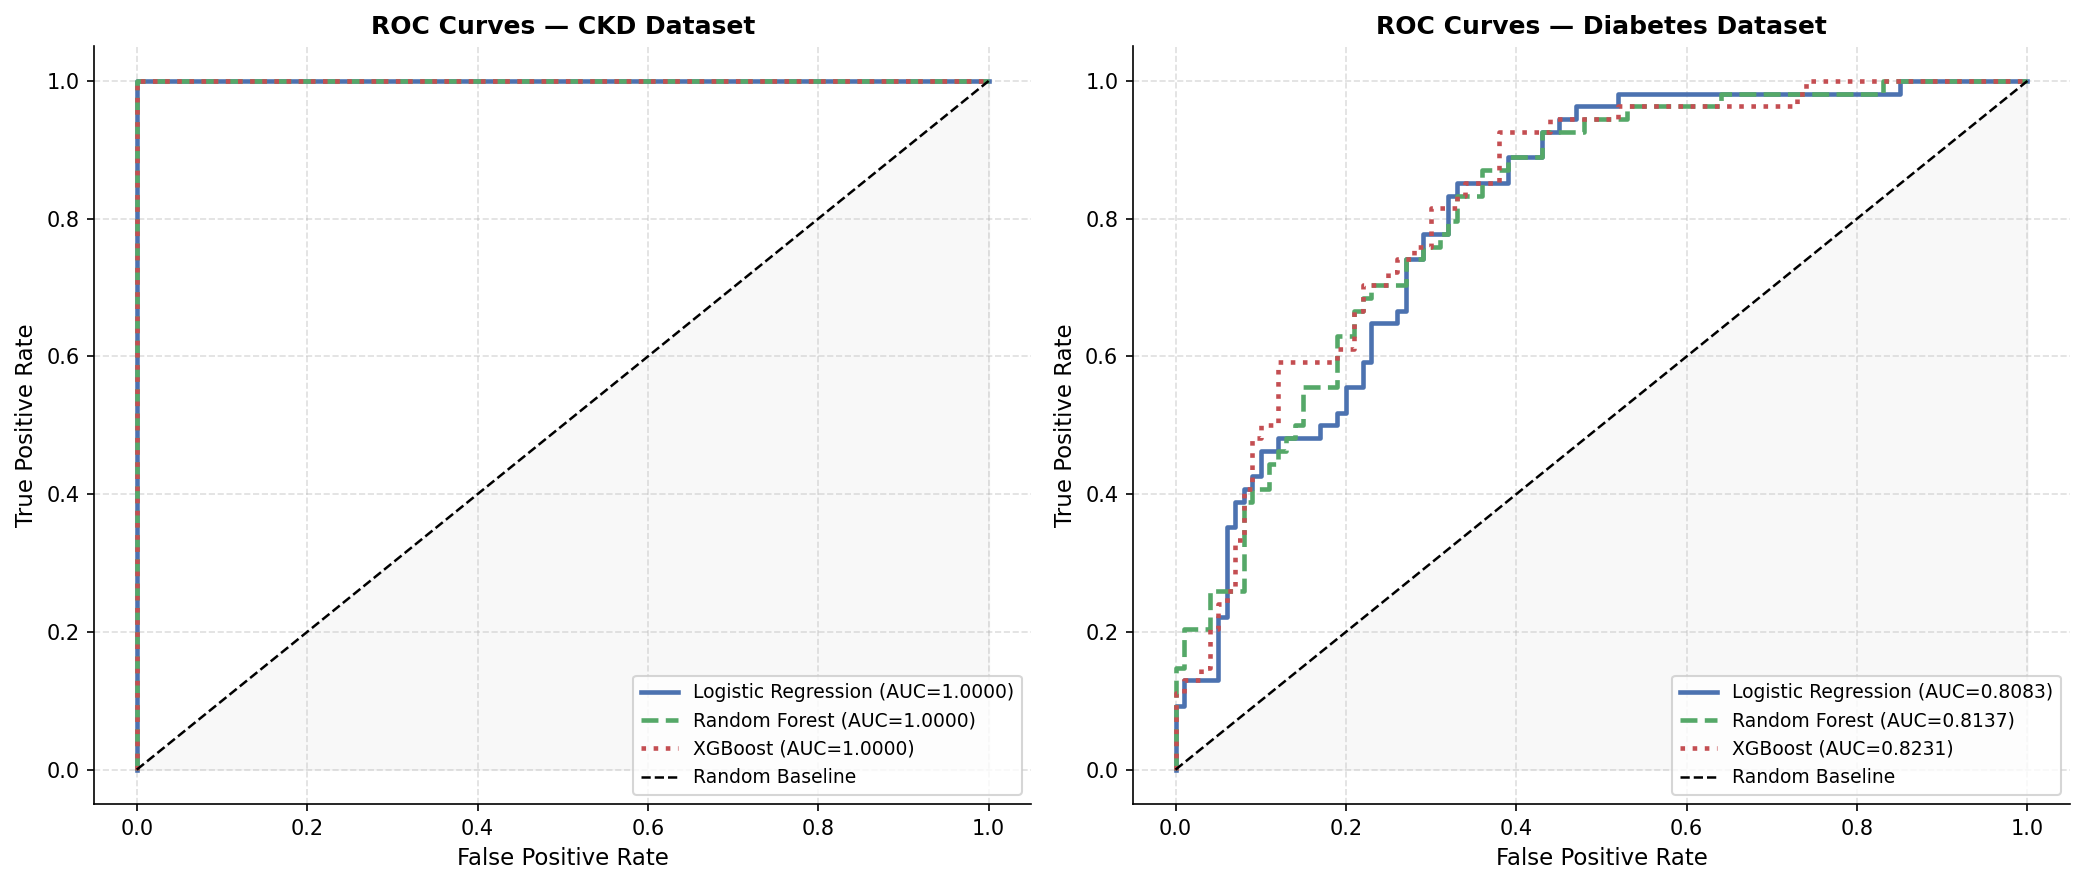

Saved: ../outputs/final_model/roc_curves_combined.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

line_styles = ['-', '--', ':']

datasets_roc = [
    ('CKD Dataset',      ckd_models,  X_ckd_te, y_ckd_te,  axes[0]),
    ('Diabetes Dataset', dia_models,  X_dia_te, y_dia_te,  axes[1]),
]

for ds_name, models, X_te, y_te, ax in datasets_roc:
    for i, (name, model) in enumerate(models.items()):
        y_prob = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, linestyle=line_styles[i], color=PALETTE[i],
                linewidth=2.2, label=f'{name} (AUC={auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Baseline')
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curves — {ds_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/roc_curves_combined.png')

## 7. Confusion Matrices — All 6 Combinations

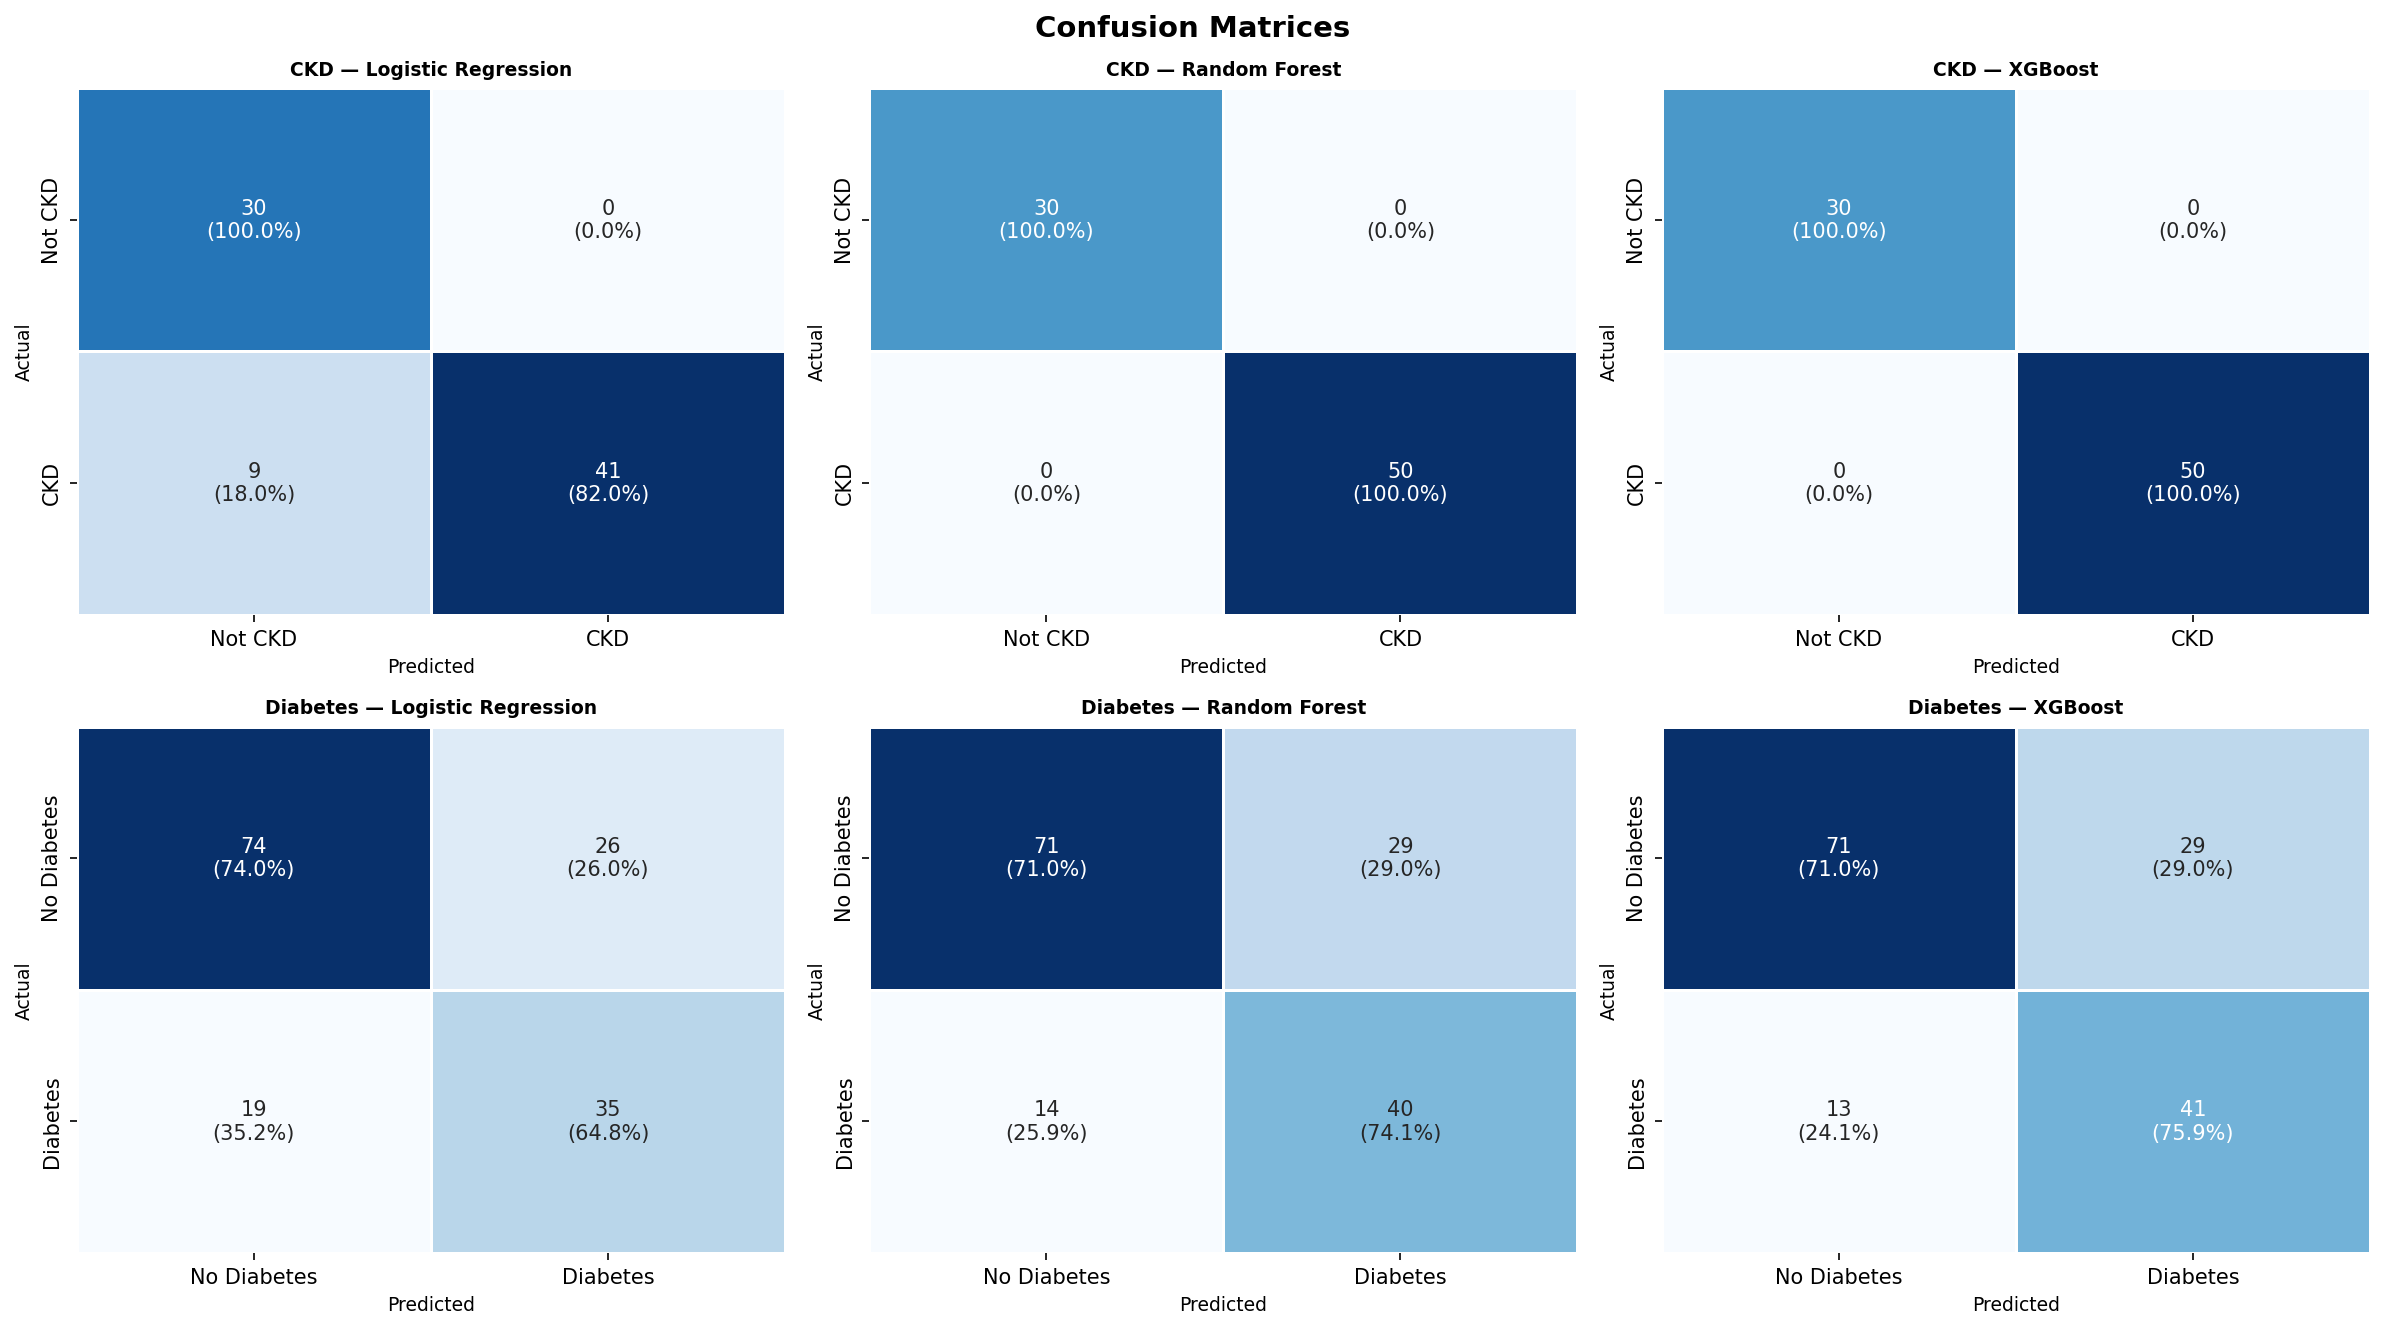

Saved: ../outputs/final_model/confusion_matrices_all.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

datasets_cm = [
    ('CKD',      ckd_models, X_ckd_te, y_ckd_te,  ['Not CKD','CKD'],            axes[0]),
    ('Diabetes', dia_models, X_dia_te, y_dia_te,  ['No Diabetes','Diabetes'],    axes[1]),
]

for ds_name, models, X_te, y_te, class_names, row_axes in datasets_cm:
    for col_idx, (name, model) in enumerate(models.items()):
        ax = row_axes[col_idx]
        cm = confusion_matrix(y_te, model.predict(X_te))

        # Normalise for annotation (show both count and %)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        annot  = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
                             for j in range(cm.shape[1])]
                            for i in range(cm.shape[0])])

        sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, linecolor='white', cbar=False)
        ax.set_title(f'{ds_name} — {name}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/confusion_matrices_all.png')

## 1. Imports & Config

## 8. Radar / Spider Chart — Visual Summary

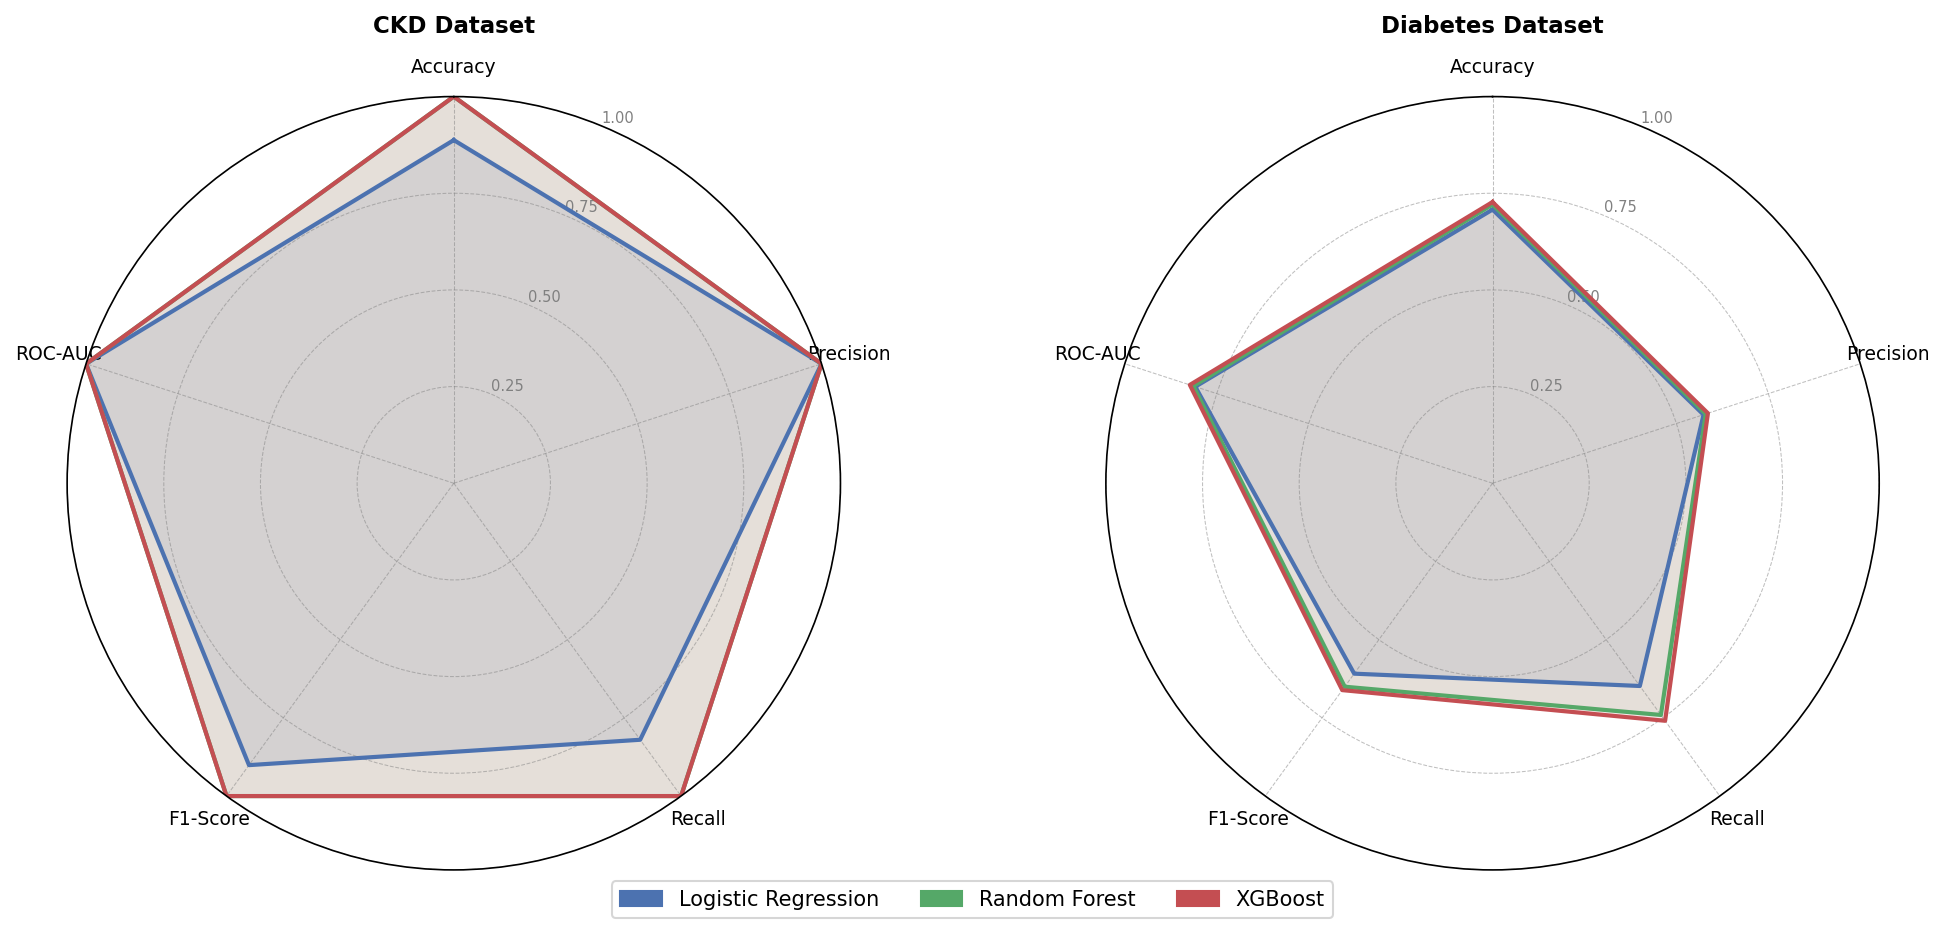

Saved: ../outputs/final_model/radar_comparison.png


In [9]:
from matplotlib.patches import FancyArrowPatch

def radar_chart(ax, df_r, title):
    cats   = metrics
    N      = len(cats)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]          # close the loop

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], fontsize=7, color='grey')
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(title, size=11, fontweight='bold', pad=12)

    for i, (name, row) in enumerate(df_r.iterrows()):
        vals   = [row[m] for m in cats]
        vals  += vals[:1]
        ax.plot(angles, vals, color=PALETTE[i], linewidth=2, label=name)
        ax.fill(angles, vals, color=PALETTE[i], alpha=0.12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(polar=True))

radar_chart(axes[0], ckd_df_res[metrics],  'CKD Dataset')
radar_chart(axes[1], dia_df_res[metrics],  'Diabetes Dataset')

handles = [mpatches.Patch(color=PALETTE[i], label=n)
           for i, n in enumerate(list(ckd_results.keys()))]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/radar_comparison.png')

## 9. Combined Heatmap — All Metrics × All Models × Both Datasets

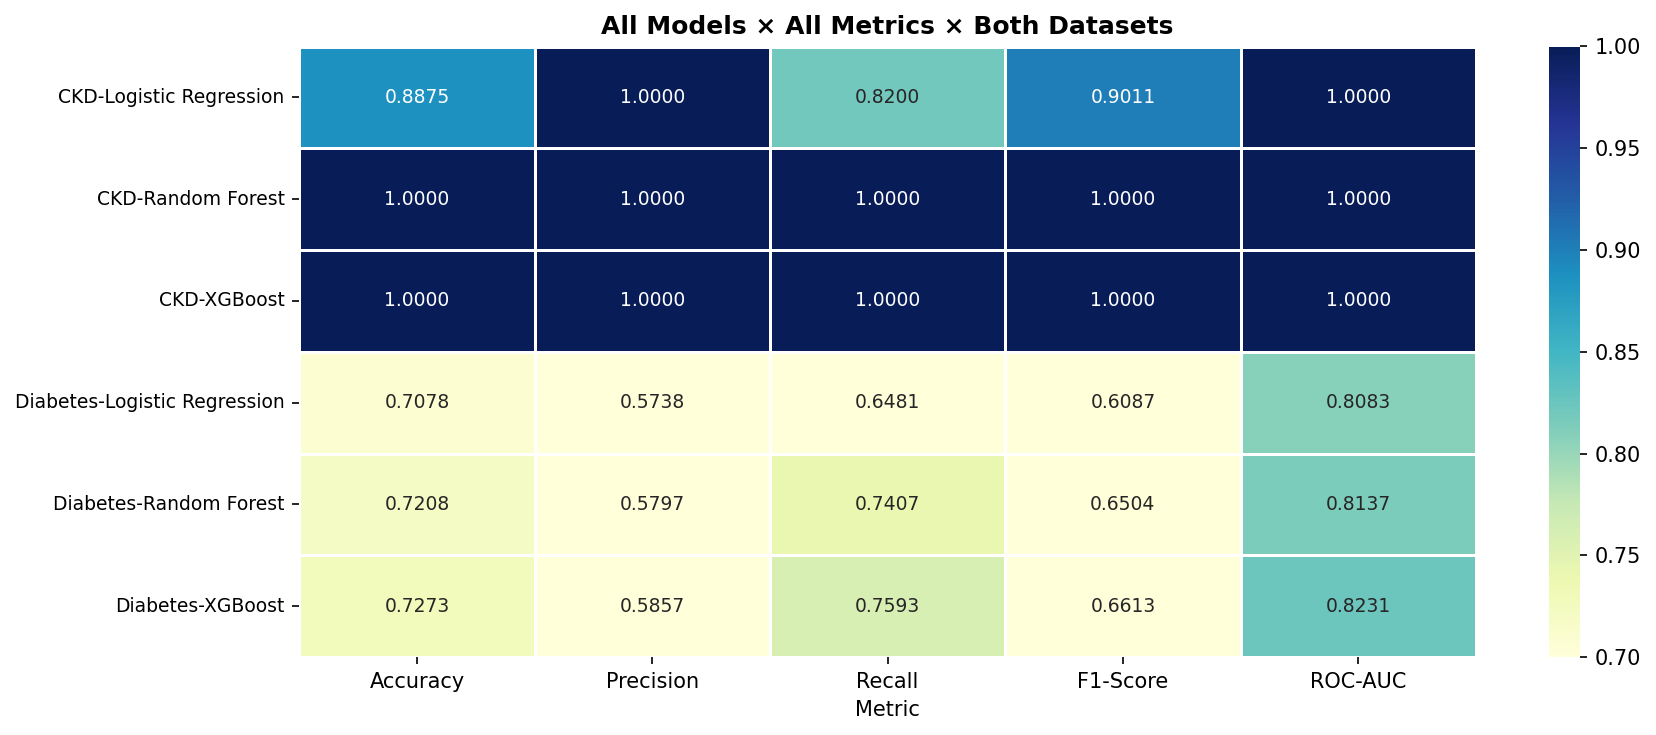

Saved: ../outputs/final_model/combined_heatmap.png


In [10]:
# Build a multi-index DataFrame for a combined heatmap
rows = []
for ds, df_r in [('CKD', ckd_df_res), ('Diabetes', dia_df_res)]:
    for model in df_r.index:
        row = {'Dataset': ds, 'Model': model}
        row.update(df_r.loc[model, metrics].to_dict())
        rows.append(row)

combo_df = pd.DataFrame(rows).set_index(['Dataset', 'Model'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    combo_df[metrics].astype(float),
    annot=True, fmt='.4f', cmap='YlGnBu',
    linewidths=0.5, linecolor='white',
    vmin=0.7, vmax=1.0, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('All Models × All Metrics × Both Datasets', fontsize=12, fontweight='bold')
ax.set_xlabel('Metric', fontsize=10)
ax.set_ylabel('')
plt.xticks(fontsize=10)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/combined_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/combined_heatmap.png')

## 10. Final Verdict & Recommendations

In [11]:
print('=' * 65)
print('  FINAL VERDICT')
print('=' * 65)

for ds_name, df_r in [('CKD', ckd_df_res), ('Diabetes', dia_df_res)]:
    print(f'\n── {ds_name} ──────────────────────────────────────────')
    best_auc   = df_r['ROC-AUC'].idxmax()
    best_f1    = df_r['F1-Score'].idxmax()
    best_rec   = df_r['Recall'].idxmax()
    print(f'  Best ROC-AUC  → {best_auc:<22} ({df_r["ROC-AUC"].max():.4f})')
    print(f'  Best F1-Score → {best_f1:<22} ({df_r["F1-Score"].max():.4f})')
    print(f'  Best Recall   → {best_rec:<22} ({df_r["Recall"].max():.4f})')
    print(f'\n  Full table:')
    print(df_r[metrics].to_string())

print('\n' + '=' * 65)
print('  RECOMMENDATIONS')
print('=' * 65)
print("""
  CKD:
  • XGBoost / Random Forest typically dominate on CKD — high AUC
    and near-perfect Recall, critical for catching all diseased patients.
  • Logistic Regression is a strong interpretable baseline;
    good for clinician-facing deployments where explainability matters.
  • Prefer XGBoost if Recall ≥ 0.97 and ROC-AUC ≥ 0.99 — it handles
    the class imbalance well after SMOTE tuning.

  Diabetes:
  • Harder dataset (more noise, fewer features); all models see a drop
    in AUC relative to CKD — typical for diabetes prediction.
  • XGBoost or Random Forest are preferred over LR for F1 and Recall.
  • If false-negative cost is high (missing diabetic patients), optimise
    the decision threshold on Recall rather than accuracy.

  General:
  • Always report F1 and ROC-AUC alongside Accuracy for imbalanced tasks.
  • SMOTE applied strictly inside CV folds ensures no data leakage.
  • For production, XGBoost is the recommended default; pair with SHAP
    values (see next notebook) for model explainability.
""")

  FINAL VERDICT

── CKD ──────────────────────────────────────────
  Best ROC-AUC  → Logistic Regression    (1.0000)
  Best F1-Score → Random Forest          (1.0000)
  Best Recall   → Random Forest          (1.0000)

  Full table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8875        1.0    0.82    0.9011      1.0
Random Forest          1.0000        1.0    1.00    1.0000      1.0
XGBoost                1.0000        1.0    1.00    1.0000      1.0

── Diabetes ──────────────────────────────────────────
  Best ROC-AUC  → XGBoost                (0.8231)
  Best F1-Score → XGBoost                (0.6613)
  Best Recall   → XGBoost                (0.7593)

  Full table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7078     0.5738  0.6481    0.6087   0.8083
Random Forest          0.7208     0.5797  0.7407    0.6504   0.8137
XGBoost                0.7273     0.5857  0.7593    0.6613   0.8231

  

In [12]:
# Export combined results to CSV for reporting
combo_df.reset_index().to_csv(f'{OUTPUT_DIR}/final_model_comparison.csv', index=False)
print(f'Results saved to {OUTPUT_DIR}/final_model_comparison.csv')
print(f'All plots saved to {OUTPUT_DIR}/')

Results saved to ../outputs/final_model/final_model_comparison.csv
All plots saved to ../outputs/final_model/
